# Joint Perturb-seq Perturbation Analysis

Jin et al. 2020 (*Nature Neuroscience*) used Perturb-seq to map the transcriptional
effects of neuronal gene knockdowns in excitatory neurons.

This tutorial uses a subset of the data to demonstrate the full **causarray** workflow:
- **29 perturbations**, ~2 900 cells, ~3 200 genes
- Data downloaded from the [Broad Single Cell Portal](https://singlecell.broadinstitute.org/single_cell/study/SCP1184)

**Pipeline overview**
```
perturbseq-exneu.h5ad
      |
      v  prep_causarray_data
   Y, A, X
      |
      v  estimate_r  →  select r (JIC criterion)
      |
      v  fit_gcate   →  estimate latent confounders U
      |
      v  LFC         →  doubly-robust log-fold changes
```

In [1]:
import os 
import sys
sys.path.append('../../..')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scanpy as sc

from causarray import prep_causarray_data, fit_gcate, LFC

The data can be downloaded from the Broad Single Cell Portal
(https://singlecell.broadinstitute.org/single_cell/study/SCP1184).
Here we use a pre-processed subset saved as `perturbseq-exneu.h5ad`.

In [2]:
adata = sc.read_h5ad('perturbseq-exneu.h5ad')
adata

AnnData object with n_obs × n_vars = 2926 × 3221
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'nGene', 'nUMI', 'Cluster', 'Batch', 'CellType', 'Perturbation', 'isKey', 'isAnalysed', 'SCRUBLET'

For running causarray, we require the following inputs:

- `Y`: the cell-by-gene gene expression matrix.
- `A`: the cell-by-condition binary matrix of the perturbation/treatment conditions.
- `X, X_A`: (optional) the cell-by-covariate matrix of the covariates of interest for outcome and propensity models.

Here, `Y` and `A` can be dataframes.

In [3]:
Y = pd.DataFrame(adata.X.copy(), columns=adata.var.index)
A = pd.get_dummies(adata.obs['Perturbation'], columns=['Perturbation'], drop_first=False).drop(columns=['GFP'])

Y, A, X, X_A = prep_causarray_data(Y, A)
a = A.shape[1]
a

29

### Number of latent factors

We estimate the number of unmeasured confounders *r* using the JIC criterion.
JIC is a penalised-likelihood score computed by fitting GCATE for each candidate
value of *r*; the optimal *r* minimises JIC.

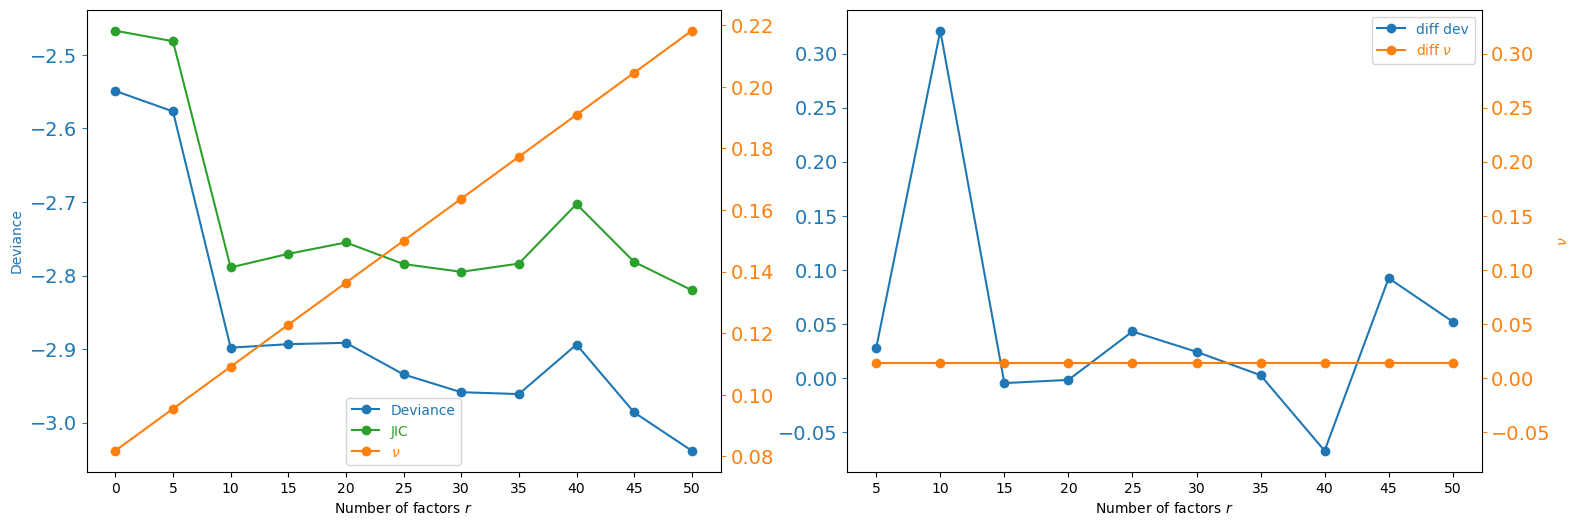

In [4]:
from causarray import estimate_r, plot_r
# df_r = estimate_r(Y, X, A, np.arange(5,55,5))
# df_r.to_csv('perturbseq-r.csv', index=False)
df_r = pd.read_csv('perturbseq-r.csv')
fig = plot_r(df_r)

### Estimate unmeasured confounders

We run **GCATE** with the selected *r* to estimate latent factors that capture
unmeasured confounders (e.g. cell-cycle phase, technical variation).
The estimated factors are appended to the covariate matrix before calling `LFC`.

In [5]:
r = 10
res_1, res_2 = fit_gcate(Y, X, A, r, verbose=True,
    kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
    kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
)
U = res_2['U']
print(f"\nStep 1  -- epochs: {res_1['n_iter']},  best NLL: {min(res_1['hist']):.6f}")
print(f"Step 2  -- epochs: {res_2['n_iter']},  best NLL: {min(res_2['hist']):.6f}")

{'d': 30, 'n': 2926, 'p': 3221, 'r': 10}
'Estimating initial latent variables with GLMs...'
'Fitting nb GLM (fast)...'


'Estimating initial coefficients with GLMs...'
'Fitting nb GLM (fast)...'


{'kwargs_es': {'max_iters': 30,
               'patience': 5,
               'rel_tol': 0.0002,
               'tolerance': 0.0,
               'warmup': 0},
 'kwargs_glm': {'disp_glm': array([ 1.11673516,  1.06870944,  1.16716468, ..., 12.58818245,
       16.46897663,  1.70852614], shape=(3221,)),
                'family': 'nb',
                'size_factor': array([0.53193358, 0.87362742, 1.2235467 , ..., 0.5593801 , 0.73025856,
       0.77857223], shape=(2926,))},
 'kwargs_ls': {'C': 1000.0,
               'alpha': 0.1,
               'beta': 0.5,
               'max_iters': 20,
               'recheck_interval': 10,
               'sparsity_boost': 2.0,
               'sparsity_threshold': 0.5,
               'tol': 0.0001,
               'tol_cell': 0.0001,
               'tol_gene': 0.0001,
               'warmup_iters': 0}}
'Fitting GCATE (step 1)...'


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:09<?, ?it/s, nll=1.71]

...

 97%|█████████▋| 29/30 [00:19<00:00,  1.95it/s, nll=1.72]

 97%|█████████▋| 29/30 [00:20<00:00,  1.95it/s, nll=1.72]

100%|██████████| 30/30 [00:20<00:00,  1.96it/s, nll=1.72]

100%|██████████| 30/30 [00:20<00:00,  1.50it/s, nll=1.72]


Step 1  -- epochs: 29,  best NLL: 1.705777
Step 2  -- epochs: 29,  best NLL: 1.722559


### Estimate log-fold change based on counterfactuals

Next, we apply causarray to estimate the causal effects of perturbations on gene expression.

In [6]:
offsets = np.log(res_2['kwargs_glm']['size_factor']) # use the precomputed size factors
df_res, estimation = LFC(Y, np.c_[X, U], A, np.c_[X_A, U], offset=offsets, usevar='pooled', verbose=True)

'Estimating LFC...'
{'a': 29, 'd': 11, 'd_A': 12, 'estimands': 'LFC', 'n': 2926, 'p': 3221}
{'C': 1.0,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
{'offset': array([-0.63123664, -0.13510128,  0.20175377, ..., -0.58092607,
       -0.31435661, -0.25029351], shape=(2926,)),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'


'Fit outcome models...'


'Fitting nb GLM (fast)...'


('Fast GLM coefficients exceed bound (max|B|=1.53e+05 > 1e+04); falling back '
 'to statsmodels...')
'Estimating dispersion parameter...'
'Fitting poisson GLM with offset...'


'Fitting nb GLM with offset...'


...

 76%|███████▌  | 22/29 [00:01<00:00, 15.20it/s]

 83%|████████▎ | 24/29 [00:01<00:00, 14.60it/s]

 90%|████████▉ | 26/29 [00:01<00:00, 14.86it/s]

 97%|█████████▋| 28/29 [00:02<00:00, 13.87it/s]

100%|██████████| 29/29 [00:02<00:00, 14.00it/s]

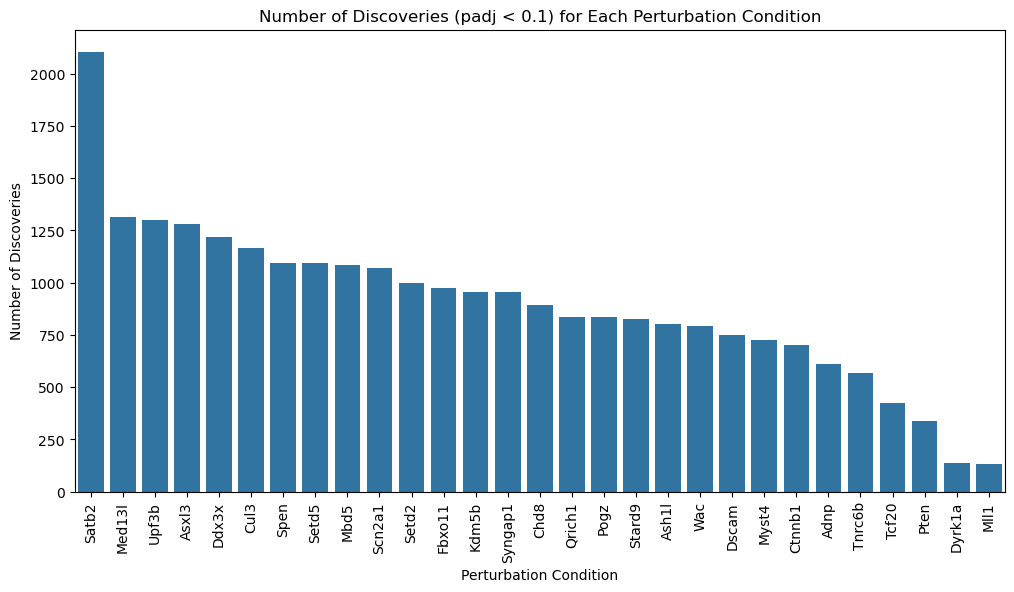

Total significant gene-perturbation pairs (padj < 0.1): 25,981
Perturbation  Count
       Satb2   2105
      Med13l   1315
       Upf3b   1299
       Asxl3   1282
       Ddx3x   1217
        Cul3   1165
        Spen   1093
       Setd5   1093
        Mbd5   1085
      Scn2a1   1071
       Setd2    997
      Fbxo11    975
       Kdm5b    957
     Syngap1    957
        Chd8    893
      Qrich1    837
        Pogz    834
      Stard9    825
       Ash1l    802
         Wac    794
       Dscam    751
       Myst4    725
      Ctnnb1    704
        Adnp    609
      Tnrc6b    568
       Tcf20    423
        Pten    337
      Dyrk1a    136
        Mll1    132


In [7]:
# Filter the results for significant discoveries
significant_discoveries = df_res[df_res['padj'] < 0.1]

# Count the number of discoveries for each perturbation condition
discovery_counts = significant_discoveries['trt'].value_counts().reset_index()
discovery_counts.columns = ['Perturbation', 'Count']

# Plot the number of discoveries for each perturbation condition
plt.figure(figsize=(12, 6))
sns.barplot(data=discovery_counts, x='Perturbation', y='Count')
plt.xticks(rotation=90)
plt.title('Number of Discoveries (padj < 0.1) for Each Perturbation Condition')
plt.xlabel('Perturbation Condition')
plt.ylabel('Number of Discoveries')
plt.show()
print(f"Total significant gene-perturbation pairs (padj < 0.1): {len(significant_discoveries):,}")
print(discovery_counts.to_string(index=False))

We can also inspect the distribution of propensity scores, to make sure the doubly-robust estimation procedure is reliable. 

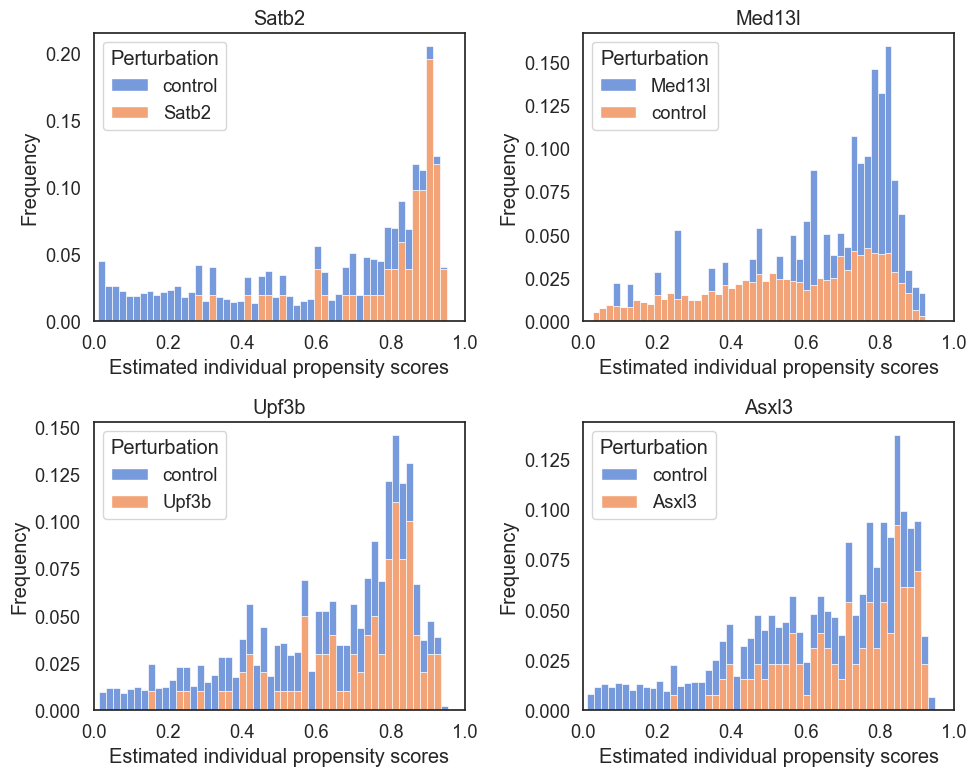

In [8]:
sns.set(font_scale=1.2, style="white")
fig, axes = plt.subplots(2,2,figsize=(10,8))
for i in range(2):
    for j in range(2):
        pert = discovery_counts['Perturbation'][i*2+j]
        a = np.where(A.columns == pert)[0][0]
        _df = pd.DataFrame({
            'value': estimation['pi_hat'][:,a],
            'Perturbation': ['control' if i==0 else pert for i in A.values[:,a]]
        })
        sns.histplot(data=_df, x='value', hue="Perturbation",  common_norm=False,
            multiple='stack', palette='muted', bins=50, stat="probability", ax=axes[i,j])
        axes[i,j].set_xlim([0,1])
        axes[i,j].set_xlabel('Estimated individual propensity scores')
        axes[i,j].set_ylabel('Frequency')
        axes[i,j].set_title(f'{pert}')
fig.tight_layout()
plt.show()

We observe extreme values only for *Satb2*, which could lead to slightly overconfident estimates. Overall, the distributions of propensity scores are reasonable for most perturbation conditions.